In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import os
print(os.getcwd())  # Check the current working directory

d:\Fake_Job_Predictor\notebooks


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")

print("Path to dataset files:", path)

100%|██████████| 16.1M/16.1M [02:16<00:00, 124kB/s] 

Extracting files...


Path to dataset files: C:\Users\lenovo\.cache\kagglehub\datasets\shivamb\real-or-fake-fake-jobposting-prediction\versions\1


In [16]:
import os
print(os.getcwd())  # Check the current working directory

# Use an absolute path
fake_job = pd.read_csv(r"d:\Fake_Job_Predictor\data\fake_job_postings.csv")
fake_job.head()

d:\Fake_Job_Predictor\notebooks


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [17]:
fake_job.fraudulent.value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [18]:
fake_job.shape

(17880, 18)

In [19]:
fake_job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

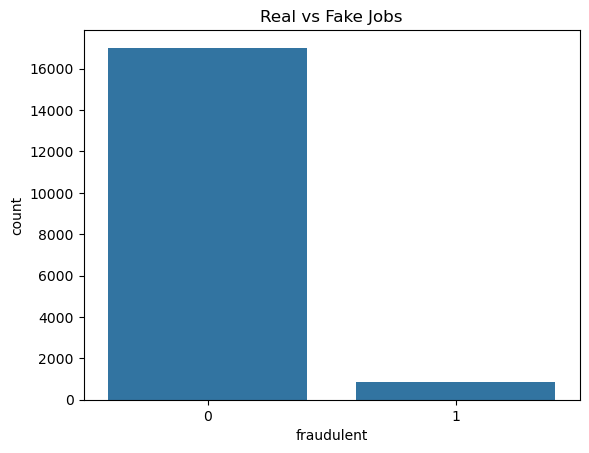

In [20]:
#imbalanced dataset
sns.countplot(x='fraudulent', data=fake_job)
plt.title("Real vs Fake Jobs")
plt.show()

In [21]:
fake_job.isna().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [22]:
fake_job.duplicated().sum()

np.int64(0)

In [23]:
#analyze the pattern
fake_job[fake_job['fraudulent']==1].head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
98,99,IC&E Technician,"US, , Stocton, CA",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abilitie...",BENEFITSWhat is offered:Competitive compensati...,0,1,1,Full-time,Mid-Senior level,High School or equivalent,Oil & Energy,Other,1
144,145,Forward Cap.,NaN,NaN,NaN,NaN,The group has raised a fund for the purchase o...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,1
173,174,Technician Instrument & Controls,US,Power Plant & Energy,NaN,Edison International and Refined Resources hav...,Technician Instrument &amp; ControlsLocation D...,JOB QUALIFICATIONS-Ability to understand proce...,"we are a team of almost 8,000 employees who he...",0,1,1,Full-time,Mid-Senior level,Certification,Electrical/Electronic Manufacturing,Other,1
180,181,Sales Executive,"PK, SD, Karachi",Sales,NaN,NaN,Sales Executive,Sales Executive,Sales Executive,0,0,0,NaN,NaN,NaN,NaN,Sales,1
215,216,IC&E Technician Mt Poso,"US, CA, Bakersfield, CA / Mt. Poso",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abiliti...",BENEFITSWhat is offered:Competitive compensati...,0,1,1,Full-time,Mid-Senior level,High School or equivalent,Oil & Energy,Other,1


In [24]:
fake_job['descr_len'] = fake_job['description'].str.len()
fake_job[fake_job['fraudulent']==1].head()

fake_job.groupby('fraudulent')['descr_len'].mean()

#you can observe description length of fake jobs is less

fraudulent
0    1221.205595
1    1156.144509
Name: descr_len, dtype: float64

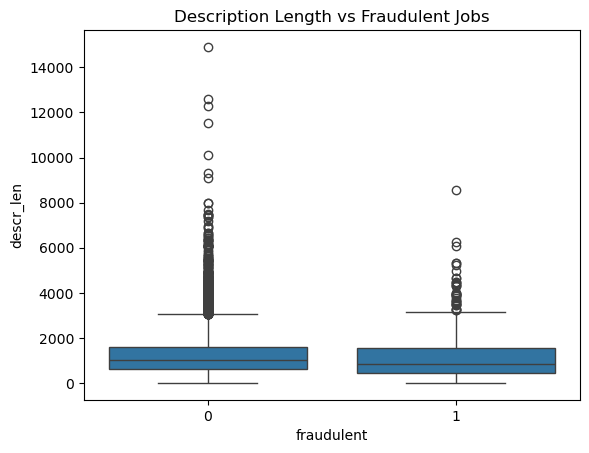

In [25]:
sns.boxplot(x='fraudulent', y='descr_len', data=fake_job)
plt.title("Description Length vs Fraudulent Jobs")
plt.show()

In [26]:
pd.crosstab(fake_job['salary_range'].isnull(), fake_job['fraudulent'])

fraudulent,0,1
salary_range,,
False,2645,223
True,14369,643


<Axes: xlabel='salary_range', ylabel='count'>

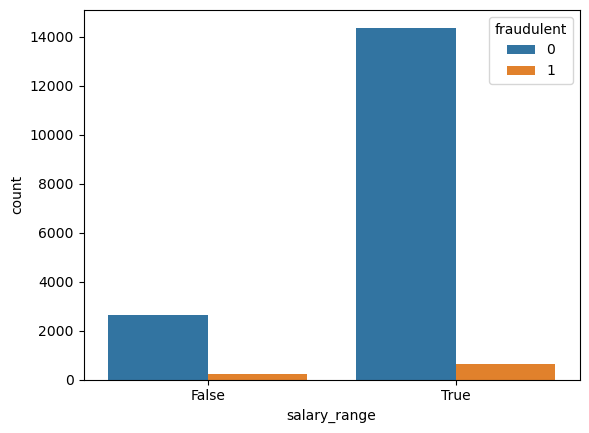

In [27]:
sns.countplot(x=fake_job['salary_range'].isnull(), hue=fake_job['fraudulent'])

In [28]:
pd.crosstab(fake_job['company_profile'].isnull(), fake_job['fraudulent'])

fraudulent,0,1
company_profile,,
False,14293,279
True,2721,587


##### 1 Fake jobs are only 5% of dataset
##### 2 Fake jobs often have shorter descriptions
##### 3 Fake jobs often hide company profile
##### 4 Fake jobs often hide salary

In [29]:
fake_job.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,descr_len
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,905.0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,2077.0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,355.0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,2600.0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,1520.0


In [30]:
fake_job = fake_job[['title','location','company_profile','description','requirements','benefits','fraudulent']]

In [31]:
fake_job.fillna("",inplace=True)

In [32]:
fake_job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            17880 non-null  object
 1   location         17880 non-null  object
 2   company_profile  17880 non-null  object
 3   description      17880 non-null  object
 4   requirements     17880 non-null  object
 5   benefits         17880 non-null  object
 6   fraudulent       17880 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 977.9+ KB


In [33]:
fake_job['text'] = (
    fake_job['title'] + " " +
    fake_job['location'] + " " +
    fake_job['company_profile'] + " " +
    fake_job['description'] + " " +
    fake_job['requirements'] + " " +
    fake_job['benefits']
)

In [34]:
fake_job[['text','fraudulent']].head()

,text,fraudulent
0,"Marketing Intern US, NY, New York We're Food52...",0
1,"Customer Service - Cloud Video Production NZ, ...",0
2,"Commissioning Machinery Assistant (CMA) US, IA...",0
3,"Account Executive - Washington DC US, DC, Wash...",0
4,"Bill Review Manager US, FL, Fort Worth SpotSou...",0


In [35]:
fake_job = fake_job[['text','fraudulent']]

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english',max_features=5000)

In [37]:
X= vectorizer.fit_transform(fake_job['text'])
X.shape

(17880, 5000)

In [38]:
Y = fake_job['fraudulent']

In [39]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [40]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2095055 stored elements and shape (14304, 5000)>

In [41]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [42]:
model.intercept_

array([-2.71132631])

In [43]:
model.coef_

array([[ 0.13245575,  2.76475742, -0.18332378, ..., -0.13285814,
        -0.10105456, -0.05560541]])

In [44]:
y_pred = model.predict(x_test)

In [45]:
from sklearn.metrics import confusion_matrix,recall_score,precision_score

confusion_matrix(y_test,y_pred)

array([[3395,    0],
       [ 100,   81]])

In [46]:
recall_score(y_test,y_pred)

0.44751381215469616

<Axes: >

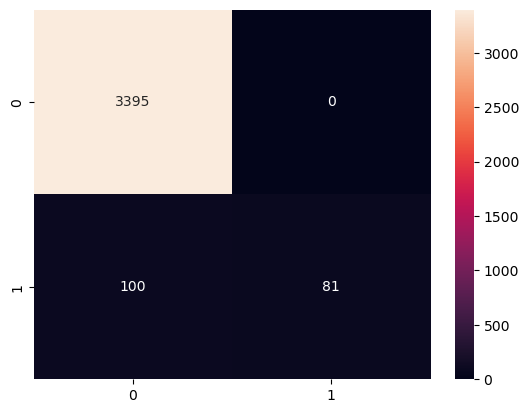

In [47]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')

In [48]:
from sklearn.linear_model import LogisticRegression
#ridge
model_l2 = LogisticRegression(
    penalty='l2',
    max_iter=1000
)

model_l2.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [49]:
y_pred_l2 = model_l2.predict(x_test)

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_l2))
print("Precision:", precision_score(y_test, y_pred_l2))
print("Recall:", recall_score(y_test, y_pred_l2))
print("F1 Score:", f1_score(y_test, y_pred_l2))

Accuracy: 0.9720357941834452
Precision: 1.0
Recall: 0.44751381215469616
F1 Score: 0.6183206106870229


In [51]:
#lasso
model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

model_l1.fit(x_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [52]:
y_pred_l1 = model_l1.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_l1))
print("Precision:", precision_score(y_test, y_pred_l1))
print("Recall:", recall_score(y_test, y_pred_l1))
print("F1 Score:", f1_score(y_test, y_pred_l1))

Accuracy: 0.9739932885906041
Precision: 0.9489795918367347
Recall: 0.5138121546961326
F1 Score: 0.6666666666666666


In [53]:
model_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model_balanced.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [54]:
y_pred_bal = model_balanced.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall:", recall_score(y_test, y_pred_bal))
print("F1 Score:", f1_score(y_test, y_pred_bal))

Accuracy: 0.9695190156599552
Precision: 0.6475409836065574
Recall: 0.8729281767955801
F1 Score: 0.7435294117647059


In [55]:
feature_names = vectorizer.get_feature_names_out()

In [56]:
coefficients = model_balanced.coef_[0]

In [57]:
coef_df = pd.DataFrame({
    'word': feature_names,
    'coef': coefficients
})

In [58]:
fake_words = coef_df.sort_values(by='coef', ascending=False).head(20)
fake_words

,word,coef
2626,link,4.835624
1608,entry,4.151108
370,aptitude,4.061097
1464,earn,4.043074
4777,vam,3.323912
1,000,3.066235
2892,money,3.041871
845,clerk,2.964035
4365,subsea,2.946782
189,administrative,2.892401


In [59]:
real_words = coef_df.sort_values(by='coef').head(20)
real_words

,word,coef
935,companies,-4.171367
852,clients,-3.011736
1340,digital,-2.931915
2054,growing,-2.875401
850,client,-2.830108
4474,team,-2.825894
4003,search,-2.704205
3883,right,-2.703064
1575,english,-2.666295
4882,website,-2.653681


<Axes: title={'center': 'Top Words Indicating Fake Jobs'}, ylabel='word'>

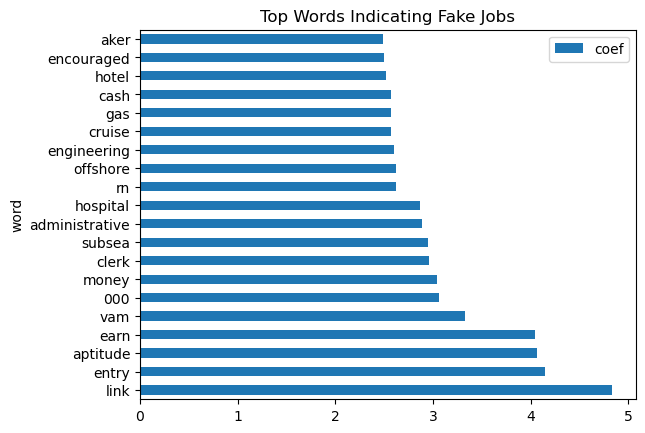

In [60]:
fake_words.plot(
    x='word',
    y='coef',
    kind='barh',
    title='Top Words Indicating Fake Jobs'
)

In [61]:
import pickle

In [62]:
pickle.dump(model_balanced, open("fake_job_model.pkl", "wb"))

In [63]:
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

In [64]:
def predict_job(text):

    vector = vectorizer.transform([text])
    prediction = model_balanced.predict(vector)

    if prediction[0] == 1:
        return "Fake Job Posting"
    else:
        return "Real Job Posting"
    
predict_job("Earn $5000 per week from home. No experience required.")


'Fake Job Posting'

In [65]:
predict_job("Software engineer required with Python and ML experience")

'Real Job Posting'